In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
from torchvision import datasets,transforms
from torchvision.models import resnet18,ResNet18_Weights
from torch.utils.data import DataLoader

In [3]:
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()])
test_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()])
train_data=datasets.ImageFolder(
    root="dataset/train",
    transform=train_transform)
test_data = datasets.ImageFolder(
    root="dataset/test",
    transform=test_transform)
train_load=DataLoader(
    train_data,
    batch_size=32,
    shuffle=True)
test_load=DataLoader(
    test_data,
    batch_size=32,
    shuffle=False)


In [4]:
weights=ResNet18_Weights.DEFAULT
model=resnet18(weights=weights)

In [5]:
for prama in model.parameters():
    prama.required_grad=False

In [6]:
model.fc = nn.Linear(model.fc.in_features,2)

In [7]:
model=model.to(device)

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer=optim.Adam(model.fc.parameters(),lr=0.001)

In [9]:
epochs=10

In [10]:
for epoch in range(epochs):
    model.train()
    running_loss=0
    for images,labels in train_load:
        images=images.to(device)
        labels=labels.to(device)
        optimizer.zero_grad()
        output=model(images)
        loss=criterion(output,labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    print(f" epoch : {epoch+1}/{epochs}  Loss : {running_loss/len(train_load):.4f}")

 epoch : 1/10  Loss : 0.5255
 epoch : 2/10  Loss : 0.2322
 epoch : 3/10  Loss : 0.1761
 epoch : 4/10  Loss : 0.1999
 epoch : 5/10  Loss : 0.1417
 epoch : 6/10  Loss : 0.1131
 epoch : 7/10  Loss : 0.1266
 epoch : 8/10  Loss : 0.1131
 epoch : 9/10  Loss : 0.0849
 epoch : 10/10  Loss : 0.0946


In [11]:
model.eval()
correct=0
total=0
with torch.no_grad():
    for images,labels in train_load:
        images=images.to(device)
        labels=labels.to(device)
        output=model(images)
        prediction = output.argmax(dim=1)
        correct += (prediction==labels).sum().item()
        total += labels.size(0)
    accuracy=100*correct/total
print("accuaray : ",accuracy)

accuaray :  98.0


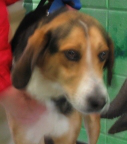

In [28]:
from PIL import Image
image=Image.open("1723.jpg")
image

In [29]:
img=test_transform(image)
img.shape

torch.Size([3, 224, 224])

In [30]:
img=img.unsqueeze(0)
img.shape

torch.Size([1, 3, 224, 224])

In [31]:
img=img.to(device)
model.eval()
with torch.no_grad():
    output=model(img)
    predict=output.argmax(dim=1)
if predict==0:
    print("It's a cat")
else:
    print("It's a dog")

It's a dog


In [32]:
torch.save(model.state_dict(),"cat vs dog.pth")